# **Homework on Credit Risk**
## **Building an Application Scoring Model**

### **General Information**
- **Date assigned:** December 2, 2025  
- **Soft deadline:** 23:59 MSK, December 15, 2025  
- **Hard deadline:** 23:59 MSK, December 18, 2025  
- **Submission:** send your work to  
  \texttt{maria.vorobyova.ser@gmail.com}  
  with the subject format:
  \[
  \text{HSE\_CS\_[track]\_FullName}
  \]
  Example:
  \[
  \text{HSE\_CS\_PAD\_IVANOV\_IVAN\_IVANOVICH}
  \]

---

### **Grading and Penalties**
Maximum score: **10 points**

Late penalty:
\[
\text{Final Score} = 10 - \text{days late}
\]

Submission **after** the hard deadline is **not accepted**.

Work must be completed **independently**.  
Similar solutions → **plagiarism** → score **0**.

---

### **Score Reduction If**
- no comments in the notebook
- unclear or poorly written code
- incorrect analysis and conclusions

---

### **Task**
Build a scoring model estimating the **probability of default** at the **credit application stage**.

Follow the provided notebook strictly and complete every block.

---

### **Dataset**
Based on Kaggle competition:
\[
\text{Give Me Some Credit}
\]

Data source:  
https://www.kaggle.com/competitions/GiveMeSomeCredit/data  

Data description:  
**Data Dictionary.xlsx**



# **Work assignment:**
**1.Explatory Data Analysis - (Task weight: 20%)**

**2.Creating additional variables - (Task weight: 10%)**

**3. Model building (A logistic regression must be built on the WoE variables.)- (Task weight: 50%)**

**4. Using methods to reduce class imbalance - (Task weight: 20%)**

# **Submitting results:**

* Submit homework via the Yandex form as a link to your GitHub, where all files and code (Python) will be.
* GitHub must be open and the code must be working, without errors.
* Name the repository using the template (HW_4_2025-FirstName_LastName).
* Link to the Yandex form: https://forms.yandex.ru/u/68eece24505690c23425594c

We wish you good luck!✌

# Additional explanations for the task

In [1]:
from google.colab import drive
import json
import zipfile

import pandas as pd

In [2]:
def load_dataset(from_kaggle:bool = False) -> pd.DataFrame:
  '''
  The function downloads data from the Kaggle website if from_kaggle=True is set.
Otherwise, the archive is read from a Google Drive link (this method is convenient for those who don't have access to Kaggle).
  params:
      - from_kaggle - индикатор откуда скачивать данные (True - c сайта kaggle, False -  c google диска)
  return:
      - pd.DataFrame

  '''
  if from_kaggle:
    # запросит разрешение к гугл диску, необходимо дать это разрешение
    drive.mount('/content/drive')
    # установим kaggle
    !pip install kaggle -q
    !mkdir ~/.kaggle
    # копируем kaggle.json (предварительно, необходимо сгенерить токен на
    # сайте kaggle и сохранить к себе на гугл диск) в папку ~/.kaggle/
    !cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/
    !kaggle competitions download -c GiveMeSomeCredit
  else:
    !gdown 1MRYG6P6ScMTzTmXJlWdPdYQVNi04wLSm
  # распаковка архива
  zip_ref = zipfile.ZipFile('GiveMeSomeCredit.zip', 'r')
  zip_ref.extractall()
  zip_ref.close()
  df_train = pd.read_csv('cs-training.csv')
  df_test = pd.read_csv('cs-test.csv')
  return df_train, df_test

In [3]:
!find "/content/drive/MyDrive" -name "kaggle.json" -type f

/content/drive/MyDrive/kaggle.json


In [4]:
df_train, df_test = load_dataset(from_kaggle=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mkdir: cannot create directory ‘/root/.kaggle’: File exists
GiveMeSomeCredit.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
df_train

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


# 1.Explatory Data Analysis. Максимально - (20%-2 балла)

- 0 points if the task is not completed
- 1 point if statistics are calculated and there are logical graphs (important, USEFUL graphs), but no conclusions are drawn
- 2 points if statistics are calculated and there are graphs (important, USEFUL graphs) and CONCLUSIONS are drawn (important, that the conclusions are correct)

In [6]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
df_train = df_train.drop(columns=['Unnamed: 0'])

Unnamed: 0 is an index and has no semantic meaning, so it is excluded from the analysis.

In [8]:
df_train['SeriousDlqin2yrs'].value_counts(normalize=True)

,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


The distribution of the target variable shows a significant imbalance between classes: the proportion of defaults is around 6.7%, while non-defaulting customers account for over 93%.

In [9]:
df_train.isna().sum().sort_values(ascending=False)

,0
MonthlyIncome,29731
NumberOfDependents,3924
SeriousDlqin2yrs,0
age,0
RevolvingUtilizationOfUnsecuredLines,0
DebtRatio,0
NumberOfTime30-59DaysPastDueNotWorse,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


Main zeroes are in MonthlyIncome and NumberOfDependents

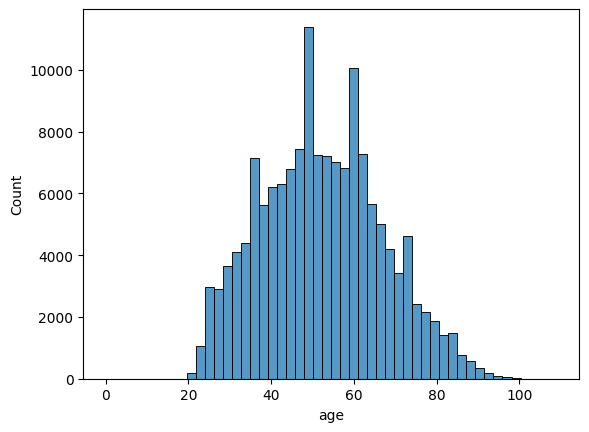

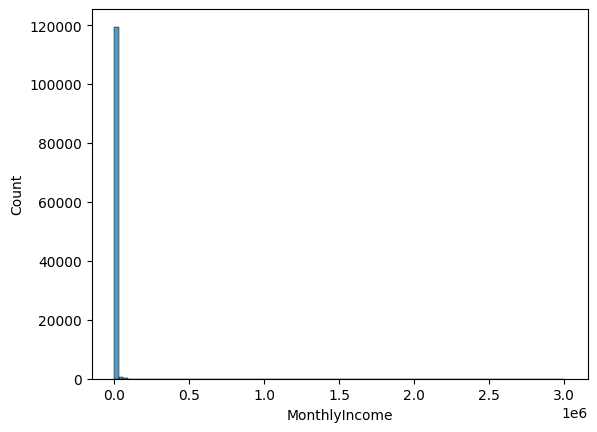

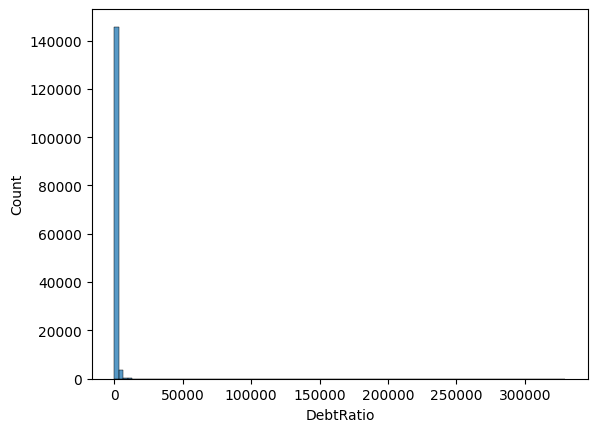

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_train['age'], bins=50)
plt.show()
sns.histplot(df_train['MonthlyIncome'], bins=100)
plt.show()
sns.histplot(df_train['DebtRatio'], bins=100)
plt.show()

The age distribution of customers is close to unimodal and appears plausible, but there are extreme values, including zero age and values older than 100 years, which indicates possible anomalies in the data.

The distribution of monthly income is skewed to the right and contains extreme values that significantly exceed the median. This indicates the presence of outliers and confirms the need for additional processing of the feature, such as logarithmic transformation or clipping.

A similar situation is observed for the DebtRatio feature, where most observations are concentrated near zero, but there are extremely large values. Such outliers can negatively affect models that are sensitive to the scale of features.

<Axes: xlabel='SeriousDlqin2yrs', ylabel='age'>

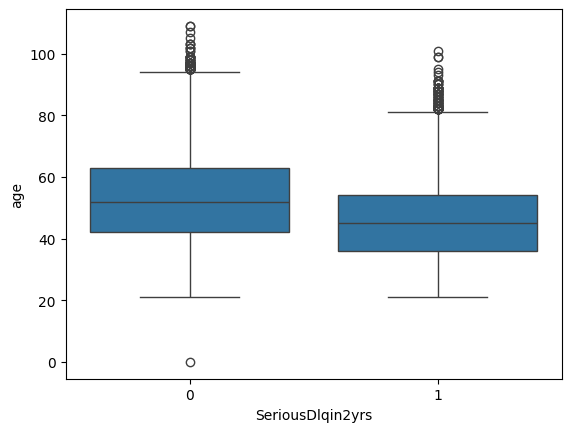

In [11]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=df_train)

The boxplot shows that customers with defaults (SeriousDlqin2yrs = 1) are on average younger than customers without defaults. The median age of defaulting borrowers is lower, and the distribution is skewed towards younger values.

This indicates a relationship between age and the probability of default,
younger customers have a higher risk of loan default, which makes the age feature potentially informative for the model.

<Axes: >

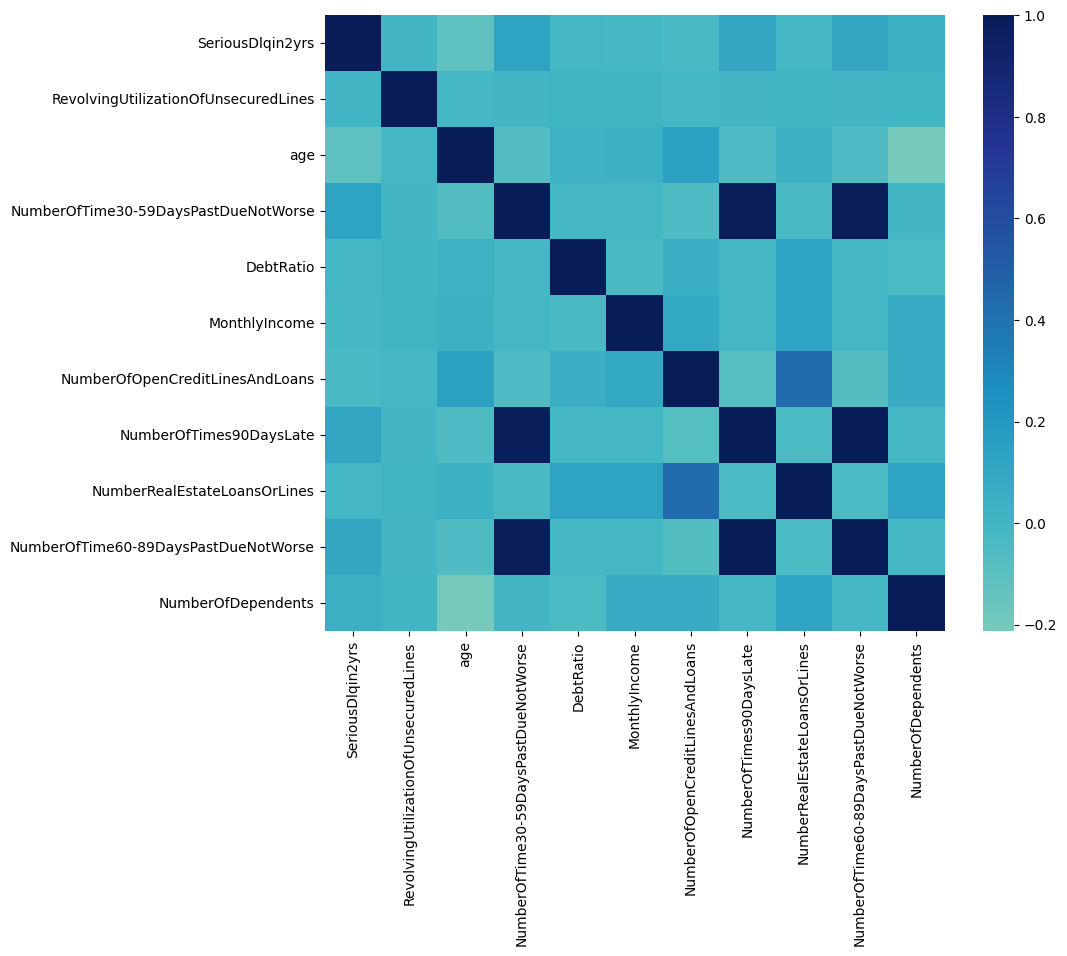

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(), cmap="YlGnBu", center=0)

Correlation analysis shows that the strongest correlation with the target variable is observed for features related to payment history (NumberOfTimes90DaysLate, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse).

During EDA, class imbalances, missing values and a significant number of outliers in economic features were identified. The most informative features for predicting default are those related to the history of delinquencies and the age of the customer. The results indicate the need for preliminary data processing before building models.

# Data preprocessing

In [13]:
median_income = df_train['MonthlyIncome'].median()
df_train['MonthlyIncome'] = df_train['MonthlyIncome'].fillna(median_income)

Almost 20% of customers did not indicate their income, so i filled them with median.

In [14]:
df_train['DependentsMissing'] = df_train['NumberOfDependents'].isna().astype(int)
df_train['NumberOfDependents'] = df_train['NumberOfDependents'].fillna(0)

If the number of dependents is not specified, it is often 0.

In [15]:
import numpy as np
df_train.loc[df_train['age'] == 0, 'age'] = np.nan
df_train.loc[df_train['age'] > 100, 'age'] = np.nan

df_train['AgeMissing'] = df_train['age'].isna().astype(int)
df_train['age'] = df_train['age'].fillna(df_train['age'].median())

Removing anomalies in age, also fill missing values with median.

In [16]:
df_train['DebtRatio'] = df_train['DebtRatio'].clip(upper=df_train['DebtRatio'].quantile(0.99))

Debt ratio has many outliers, so i removed thwm with 99 percentile.

# 2.Creating additional variables - (Task weight: 10%)

Be creative: the more variables, the higher the score! However, variables must be logical; illogical variables will not be accepted.

- 0 points if the task is not completed.
- 0.5 points - 2 additional variables created.
- 1 point - more than 3 variables created.


In [17]:
df_train['IncomePerDependent'] = df_train['MonthlyIncome'] / (df_train['NumberOfDependents'] + 1)

In [18]:
df_train['TotalLatePayments'] = (
    df_train['NumberOfTimes90DaysLate'] +
    df_train['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_train['NumberOfTime60-89DaysPastDueNotWorse']
)

In [19]:
df_train['HasLatePayments'] = (df_train['TotalLatePayments'] > 0).astype(int)

In [20]:
df_train['DebtToIncome'] = df_train['DebtRatio'] * df_train['MonthlyIncome']

In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 17 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  float64
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
 11  

In [22]:
df_test = df_test.drop(columns=['Unnamed: 0'], errors='ignore')

median_income = df_train['MonthlyIncome'].median()
df_test['MonthlyIncome'] = df_test['MonthlyIncome'].fillna(median_income)
df_test['DependentsMissing'] = df_test['NumberOfDependents'].isna().astype(int)
df_test['NumberOfDependents'] = df_test['NumberOfDependents'].fillna(0)

df_test.loc[df_test['age'] == 0, 'age'] = np.nan
df_test.loc[df_test['age'] > 100, 'age'] = np.nan
df_test['AgeMissing'] = df_test['age'].isna().astype(int)
df_test['age'] = df_test['age'].fillna(df_train['age'].median())

dr_cap = df_train['DebtRatio'].quantile(0.99)
df_test['DebtRatio'] = df_test['DebtRatio'].clip(upper=dr_cap)

df_test['IncomePerDependent'] = df_test['MonthlyIncome'] / (df_test['NumberOfDependents'] + 1)

df_test['TotalLatePayments'] = (
    df_test['NumberOfTimes90DaysLate'] +
    df_test['NumberOfTime30-59DaysPastDueNotWorse'] +
    df_test['NumberOfTime60-89DaysPastDueNotWorse'])

df_test['HasLatePayments'] = (df_test['TotalLatePayments'] > 0).astype(int)
df_test['DebtToIncome'] = df_test['DebtRatio'] * df_test['MonthlyIncome']

Applied the same preprocessing and features to df_test

# 3. Model building - (Task weight: 50%)
A logistic regression must be built on the WoE variables.

- If any other model is built, the score is 0.

In [23]:
# Remember to split the data into test and train
from sklearn.model_selection import train_test_split
X = df_train.drop(columns=['SeriousDlqin2yrs'])
y = df_train['SeriousDlqin2yrs']
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
X_train = X_train.copy()
X_val = X_val.copy()

A WoE transformation must be calculated - maximum 3 points.

The WoE calculation must be done in two steps:

Step 1. Fine Classification (1 point). Splitting into a large number of bins (intervals).
- Typically, interval variables are divided into 20, 30, and so on intervals.
- For categorical variables, one category per group.
- Next, calculate the WoE for each group.

Step 2. Coarse Classification (2 points). Consolidating the intervals obtained in Step 1. The result should be no more than 5-10 intervals.
- Typically, groups with similar WoE values ​​are combined.
- The WoE must be monotonic, meaning that after your combination, the result must be interpretable (it is necessary to graphically demonstrate that the WoE is monotonic).


In [24]:
from pandas.api.types import is_numeric_dtype
def woe_iv_table(df, feature, target, bins=20):
    df = df[[feature, target]].copy()

    if is_numeric_dtype(df[feature]):
        df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
    else:
        df['bin'] = df[feature].astype(str)

    grouped = df.groupby('bin', dropna=False)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    grouped['bad'] = grouped['bad'].clip(lower=0)
    grouped['good'] = grouped['good'].clip(lower=0)
    grouped['bad_rate'] = (grouped['bad'] + 0.5) / (grouped['bad'].sum() + 0.5 * len(grouped))
    grouped['good_rate'] = (grouped['good'] + 0.5) / (grouped['good'].sum() + 0.5 * len(grouped))
    grouped['WoE'] = np.log(grouped['good_rate'] / grouped['bad_rate'])
    return grouped.reset_index().rename(columns={'bin': 'bin'})

Laplace smoothing was applied to avoid infinite WoE values in bins with zero events, which improves numerical stability and is standard practice in credit scoring.

In [25]:
# Fine classing
train_tmp_fine = pd.concat([X_train[['age']], y_train], axis=1)
woe_age_fine = woe_iv_table(
    train_tmp_fine,
    feature='age',
    target='SeriousDlqin2yrs',
    bins=30)

woe_age_fine.head()

/tmp/ipython-input-3449739196.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin', dropna=False)[target].agg(['count', 'sum'])


,bin,total,bad,good,bad_rate,good_rate,WoE
0,"(20.999, 27.0]",3916,444,3472,0.063202,0.035435,-0.578643
1,"(27.0, 30.0]",3636,406,3230,0.057799,0.032965,-0.561515
2,"(30.0, 33.0]",4391,480,3911,0.068321,0.039914,-0.537475
3,"(33.0, 35.0]",3047,302,2745,0.043012,0.028016,-0.428686
4,"(35.0, 37.0]",3434,332,3102,0.047277,0.031659,-0.401000


In [26]:
X_train = X_train.copy()
X_train['age_bin'] = pd.cut(X_train['age'], bins=[0, 35, 45, 55, 65, 120])
train_tmp = pd.concat([X_train[['age_bin']], y_train], axis=1)
woe_age_coarse = woe_iv_table(
    train_tmp,
    feature='age_bin',
    target='SeriousDlqin2yrs')

woe_age_coarse

,bin,total,bad,good,bad_rate,good_rate,WoE
0,"(0, 35]",14990,1632,13358,0.232533,0.136333,-0.533935
1,"(35, 45]",20947,1845,19102,0.262873,0.194954,-0.298906
2,"(45, 55]",25665,1935,23730,0.275693,0.242186,-0.129579
3,"(55, 65]",23513,1114,22399,0.158749,0.228602,0.364658
4,"(65, 120]",19885,492,19393,0.070152,0.197924,1.037224


The WoE values for age demonstrate a clear monotonic increasing trend, indicating lower default risk for older borrowers. This confirms the interpretability and suitability of the variable for logistic regression.

In [27]:
woe_age_dict = dict(zip(woe_age_coarse['bin'], woe_age_coarse['WoE']))

In [28]:
bins = [0, 35, 45, 55, 65, 120]
X_train['age_bin'] = pd.cut(X_train['age'], bins=bins)
X_val['age_bin'] = pd.cut(X_val['age'], bins=bins)
X_train['age_woe'] = X_train['age_bin'].astype(str).map(woe_age_dict)
X_val['age_woe'] = X_val['age_bin'].astype(str).map(woe_age_dict)

I recorded these intervals and created a woe variable for train and validation

In [29]:
X_train['TotalLatePayments'] = X_train['TotalLatePayments'].fillna(0)
X_val['TotalLatePayments']   = X_val['TotalLatePayments'].fillna(0)

bins_late = [-1, 0, 1, 3, 10, np.inf]
labels_late = ['0', '1', '2-3', '4-10', '10+']

X_train['late_bin'] = pd.cut(
    X_train['TotalLatePayments'],
    bins=bins_late,
    labels=labels_late,
    ordered=True)

X_val['late_bin'] = pd.cut(
    X_val['TotalLatePayments'],
    bins=bins_late,
    labels=labels_late,
    ordered=True)

In [30]:
train_tmp = pd.concat([X_train[['late_bin']], y_train], axis=1)

woe_late = woe_iv_table(
    train_tmp,
    feature='late_bin',
    target='SeriousDlqin2yrs')

woe_late

,bin,total,bad,good,bad_rate,good_rate,WoE
0,0,83730,2301,81429,0.327826,0.831045,0.930202
1,1,12041,1458,10583,0.207749,0.108012,-0.654087
2,10+,261,154,107,0.022007,0.001097,-2.998678
3,2-3,6216,1701,4515,0.242362,0.046084,-1.659969
4,4-10,2752,1404,1348,0.200057,0.013762,-2.676663


In [31]:
woe_late_dict = dict(zip(woe_late['bin'], woe_late['WoE']))

X_train['late_woe'] = X_train['late_bin'].astype(str).map(woe_late_dict)
X_val['late_woe'] = X_val['late_bin'].astype(str).map(woe_late_dict)

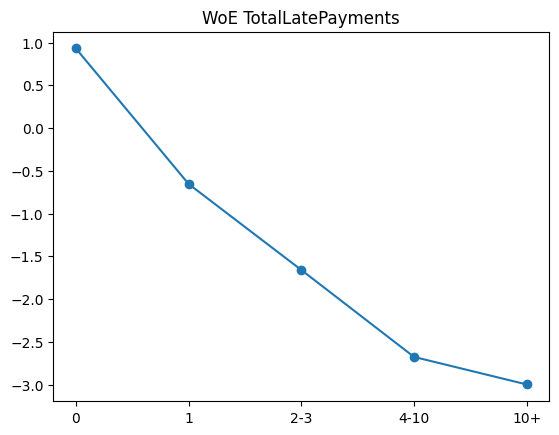

In [32]:
woe_late['bin'] = pd.Categorical(woe_late['bin'], categories=labels_late, ordered=True)
woe_late = woe_late.sort_values('bin')

plt.plot(woe_late['bin'].astype(str), woe_late['WoE'], marker='o')
plt.title('WoE TotalLatePayments')
plt.show()

The WoE values for TotalLatePayments exhibit a monotonic decreasing pattern.
An increase in the number of late payments corresponds to a higher probability of default, which confirms the predictive power and interpretability of this variable.

Constructing and evaluating logistic regression - maximum 1 point
- Constructing only logistic regression - 0.3 points
- Evaluating the model (roc auc, f1, etc.) - 0.3 points
- Constructing a scorecard - 0.4 points

As a reminder, the following formulas are required for the scorecard (details in the lecture and seminar):
Score_i =  (βi × WoE_i + α/n) × Factor + Offset/n, где

- Factor = pdo/ln(2)

- Offset = Target Score — (Factor × ln(Target Odds))

In [33]:
from sklearn.linear_model import LogisticRegression
features_woe = ['age_woe', 'late_woe']

logreg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs')

logreg.fit(X_train[features_woe], y_train)

LogisticRegression(max_iter=1000)

In [34]:
from sklearn.metrics import roc_auc_score, f1_score
y_pred_proba = logreg.predict_proba(X_val[features_woe])[:, 1]
y_pred = logreg.predict(X_val[features_woe])
roc_auc = roc_auc_score(y_val, y_pred_proba)
f1 = f1_score(y_val, y_pred)

roc_auc, f1

(np.float64(0.8193612557723761), 0.2620827105132038)

The logistic regression model was evaluated using ROC-AUC and F1-score. ROC-AUC above 0.8, f1 is moderate due to significant class imbalance

In [35]:
pdo = 20
factor = pdo / np.log(2)
target_score = 600
target_odds = 50
offset = target_score - factor * np.log(target_odds)

In [36]:
n = len(features_woe)

In [37]:
beta_age = logreg.coef_[0][features_woe.index('age_woe')]
woe_age_coarse['Score'] = ((beta_age * woe_age_coarse['WoE'] + offset / n) * factor)
woe_age_coarse[['bin', 'WoE', 'Score']]

,bin,WoE,Score
0,"(0, 35]",-0.533935,7038.955143
1,"(35, 45]",-0.298906,7033.999759
2,"(45, 55]",-0.129579,7030.429652
3,"(55, 65]",0.364658,7020.009071
4,"(65, 120]",1.037224,7005.828578


Older borrowers receive fewer penalty points

In [38]:
beta_late = logreg.coef_[0][features_woe.index('late_woe')]
woe_late['Score'] = ((beta_late * woe_late['WoE'] + offset / n) * factor)
woe_late[['bin', 'WoE', 'Score']]

,bin,WoE,Score
0,0,0.930202,7001.745945
1,1,-0.654087,7045.945912
3,2-3,-1.659969,7074.008944
4,4-10,-2.676663,7102.373626
2,10+,-2.998678,7111.357494


The scorecard assigns higher penalty points to borrowers with a greater number of late payments

The scores are high > 7000 because I distribute Offset/n across each attribute

Conduct a sample stability analysis using PSI
- Compare the test and training samples you downloaded from Kaggle (df_train, df_test)

In [39]:
def psi_numeric(expected, actual, bins=10):
    expected = pd.to_numeric(expected, errors='coerce').replace([np.inf, -np.inf], np.nan)
    actual   = pd.to_numeric(actual,   errors='coerce').replace([np.inf, -np.inf], np.nan)
    if expected.notna().sum() == 0 or actual.notna().sum() == 0:
        raise ValueError("PSI input has no finite values after cleaning (all NaN/inf).")
    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(expected.dropna().quantile(quantiles).values)

    if len(edges) < 3:
        edges = np.array([expected.min() - 1e-6, expected.max() + 1e-6])

    exp_counts = np.histogram(expected.dropna(), bins=edges)[0]
    act_counts = np.histogram(actual.dropna(),   bins=edges)[0]

    exp_perc = exp_counts / exp_counts.sum()
    act_perc = act_counts / act_counts.sum()
    exp_perc = np.clip(exp_perc, 1e-6, 1)
    act_perc = np.clip(act_perc, 1e-6, 1)

    return np.sum((exp_perc - act_perc) * np.log(exp_perc / act_perc))

In [40]:
psi_age = psi_numeric(df_train['age'], df_test['age'])
psi_income = psi_numeric(df_train['MonthlyIncome'], df_test['MonthlyIncome'])
psi_late = psi_numeric(df_train['TotalLatePayments'], df_test['TotalLatePayments'])

psi_age, psi_income, psi_late

(np.float64(9.404807259356091e-05),
 np.float64(0.00027451495101845155),
 np.float64(1.9149848041609984e-05))

psi was calculated to compare the distributions of key variables between the training and test samples. All psi values are well below 0.1,and that indicates a high degree of population stability and no evidence of distribution shift between the samples

# 4. Using methods to reduce class imbalance - (Task weight: 20%)
- Try several methods to reduce class imbalance
- Choose the one that brings the greatest improvement

In [41]:
roc_auc_base = roc_auc
f1_base = f1

In [42]:
logreg_bal = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced')

logreg_bal.fit(X_train[features_woe], y_train)
y_pred_proba_bal = logreg_bal.predict_proba(X_val[features_woe])[:, 1]
y_pred_bal = logreg_bal.predict(X_val[features_woe])
roc_auc_bal = roc_auc_score(y_val, y_pred_proba_bal)
f1_bal = f1_score(y_val, y_pred_bal)

roc_auc_bal, f1_bal

(np.float64(0.8192525645399023), 0.3470152505446623)

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(
    X_train[features_woe],
    y_train)

logreg_sm = LogisticRegression(
    max_iter=1000,
    solver='lbfgs')

logreg_sm.fit(X_train_sm, y_train_sm)

y_pred_proba_sm = logreg_sm.predict_proba(X_val[features_woe])[:, 1]
y_pred_sm = logreg_sm.predict(X_val[features_woe])
roc_auc_sm = roc_auc_score(y_val, y_pred_proba_sm)
f1_sm = f1_score(y_val, y_pred_sm)

roc_auc_sm, f1_sm

(np.float64(0.8192525645399023), 0.3470152505446623)

Both logistic regression and SMOTE led to an improvement in f1 score compared to the baseline model, but ROC-AUC remained stable.

_Optional, for those who have reached the end of the laptop_ 😊

What was your impression of the work?
What was difficult?
What was interesting?